In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv(r"C:\Users\Aasritha\Downloads\restuarant (1).csv")

df.head()

,total_bill,tip,sex,smoker,day,time,size,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,12.60,1.00,Male,Yes,Sat,Dinner,2,NaN,NaN,NaN
1,32.83,1.17,Male,Yes,Sat,Dinner,2,NaN,NaN,NaN
2,10.07,1.25,Male,No,Sat,Dinner,2,NaN,NaN,NaN
3,10.51,1.25,Male,No,Sat,Dinner,2,NaN,NaN,NaN
4,48.17,5.00,Male,No,Sun,Dinner,6,NaN,NaN,NaN


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (244, 10)
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
 7   Unnamed: 7  0 non-null      float64
 8   Unnamed: 8  0 non-null      float64
 9   Unnamed: 9  1 non-null      float64
dtypes: float64(5), int64(1), str(4)
memory usage: 19.2 KB


In [5]:
df = df.drop(columns=["Unnamed: 7", "Unnamed: 8", "Unnamed: 9"])

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,12.60,1.00,Male,Yes,Sat,Dinner,2
1,32.83,1.17,Male,Yes,Sat,Dinner,2
2,10.07,1.25,Male,No,Sat,Dinner,2
3,10.51,1.25,Male,No,Sat,Dinner,2
4,48.17,5.00,Male,No,Sun,Dinner,6


In [6]:
print(df.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [7]:
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 1


In [8]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (243, 7)


In [9]:
X = df.drop("tip", axis=1)
y = df["tip"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   total_bill   sex smoker  day    time  size
0       12.60  Male    Yes  Sat  Dinner     2
1       32.83  Male    Yes  Sat  Dinner     2
2       10.07  Male     No  Sat  Dinner     2
3       10.51  Male     No  Sat  Dinner     2
4       48.17  Male     No  Sun  Dinner     6

Target:
0    1.00
1    1.17
2    1.25
3    1.25
4    5.00
Name: tip, dtype: float64


In [10]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,total_bill,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,12.60,2,True,True,True,False,False,False
1,32.83,2,True,True,True,False,False,False
2,10.07,2,True,False,True,False,False,False
3,10.51,2,True,False,True,False,False,False
4,48.17,6,True,False,False,True,False,False


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (194, 8)
Testing data: (49, 8)


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [13]:
y_pred = model.predict(X_test)

print("First 5 predictions:")
print(y_pred[:5])

First 5 predictions:
[2.42153967 1.81103129 2.86616103 1.98266124 5.6377665 ]


In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.7747999133265202
MSE : 1.1278383629461826
RMSE: 1.0619973460165437
R²  : 0.580916353623666


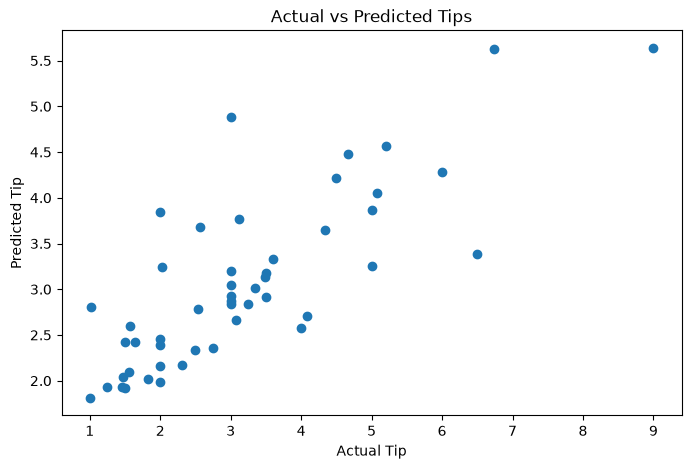

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tips")

plt.show()

## Conclusion

A Linear Regression model was built using the restaurant dataset to predict tip amounts. The dataset was explored and cleaned, and the data was divided into training and testing sets. The model was trained, predictions were made, and its performance was evaluated using MAE, MSE, RMSE, and R² score.

The model achieved an R² score of approximately 0.58, showing that it was able to explain a reasonable portion of the variation in tip amounts.